<a href="https://colab.research.google.com/github/dominicwooldridge/GSB-S544/blob/Practice-Activities/Copy_of_Practice_Activity_kNN_and_Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [2]:
pip install palmerpenguins

In [3]:
# Code Here
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
pd.get_dummies(penguins)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,39.1,18.7,181.0,3750.0,2007,True,False,False,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,2007,True,False,False,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,2007,True,False,False,False,False,True,True,False
3,NaN,NaN,NaN,NaN,2007,True,False,False,False,False,True,False,False
4,36.7,19.3,193.0,3450.0,2007,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,2009,False,True,False,False,True,False,False,True
340,43.5,18.1,202.0,3400.0,2009,False,True,False,False,True,False,True,False
341,49.6,18.2,193.0,3775.0,2009,False,True,False,False,True,False,False,True
342,50.8,19.0,210.0,4100.0,2009,False,True,False,False,True,False,False,True


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on the entire dataset:

* Your best multiple linear regression model from before
* Two kNN models (for different values of K)
* A decision tree model

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

cols_needed = ['bill_depth_mm','bill_length_mm','flipper_length_mm','body_mass_g','year']
peng = penguins.dropna(subset=cols_needed)

y = peng['bill_depth_mm']
train, test = train_test_split(peng, test_size=0.30, random_state=42)

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

model_4 = {
    "Model 4": ['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year'],
}

rows = []
for name, Xcols in model_4.items():
    m = LinearRegression().fit(train[Xcols], train[y.name])
    tr_rmse = RMSE(train[y.name], m.predict(train[Xcols]))
    te_rmse = RMSE(test[y.name],  m.predict(test[Xcols]))
    rows.append({"Model": name, "Train RMSE": tr_rmse, "Test RMSE": te_rmse})

err = pd.DataFrame(rows)
print(err)


     Model  Train RMSE  Test RMSE
0  Model 4    1.530384   1.586837


KNN

In [10]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd

peng_clean = peng.dropna(subset=['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm',
                                 'body_mass_g', 'year'])

y = peng_clean['bill_depth_mm']
X = peng_clean[['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year']]

knn_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())
])

k_values = [3, 15]
results = []

for k in k_values:
    knn_pipe.set_params(model__n_neighbors=k)

    neg_mse_scores = cross_val_score(
        knn_pipe, X, y, cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-neg_mse_scores)

    results.append({
        "k": k,
        "mean_RMSE": rmse_scores.mean()
    })

results_df = pd.DataFrame(results)
print(results_df)


    k  mean_RMSE
0   3   2.113702
1  15   1.824416


Decision Tree

In [5]:
from palmerpenguins import load_penguins
import pandas as pd

penguins = load_penguins()

cols_needed = ['bill_depth_mm','bill_length_mm','flipper_length_mm','body_mass_g','year']

peng = penguins.dropna(subset=cols_needed)

y = peng['bill_depth_mm']

X = peng[['bill_length_mm','flipper_length_mm','body_mass_g','year']]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth=4,        # you can tune this
    random_state=42
)

tree_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=4, random_state=42)

In [8]:
from sklearn.metrics import mean_squared_error

y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5

rmse


1.1015929880766493

Comparison chart

                     Model Dataset      RMSE
0        Linear Regression   Train  1.530384
1        Linear Regression    Test  1.586837
2  Decision Tree (depth=4)   Train  0.875516
3  Decision Tree (depth=4)    Test  1.228630
4                kNN (k=3)   Train  0.722904
5                kNN (k=3)    Test  1.126933


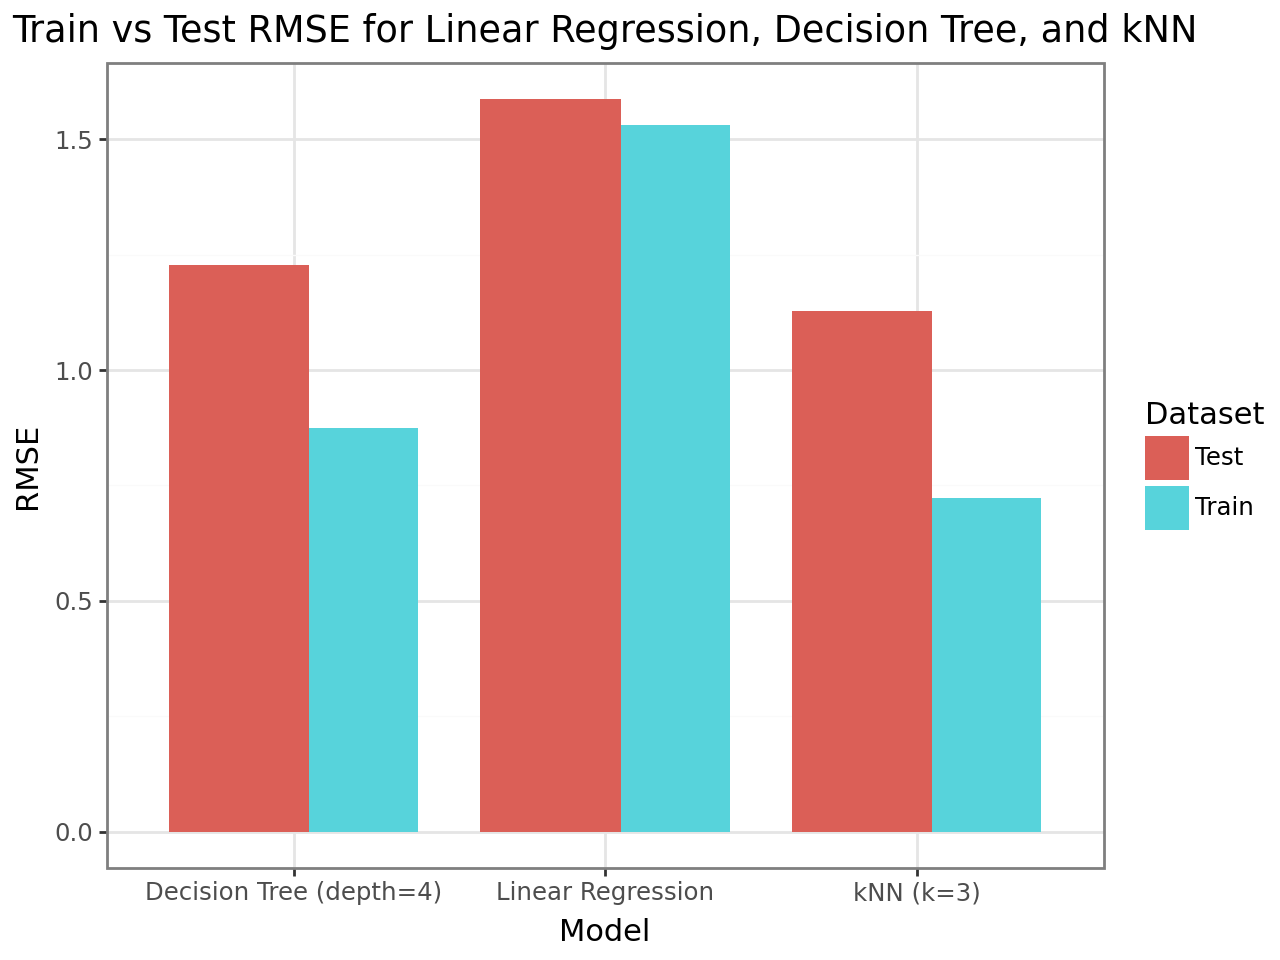

In [12]:


from plotnine import ggplot, aes, geom_col, position_dodge, labs, theme_bw

cols_needed = ['bill_depth_mm','bill_length_mm','flipper_length_mm','body_mass_g','year']
peng = penguins.dropna(subset=cols_needed)

y = peng['bill_depth_mm']
X = peng[['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'year']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))



lr = LinearRegression().fit(X_train, y_train)
lr_train_rmse = RMSE(y_train, lr.predict(X_train))
lr_test_rmse  = RMSE(y_test,  lr.predict(X_test))


tree = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_train, y_train)
tree_train_rmse = RMSE(y_train, tree.predict(X_train))
tree_test_rmse  = RMSE(y_test,  tree.predict(X_test))



knn_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=3))
])

knn_pipe.fit(X_train, y_train)
knn_train_rmse = RMSE(y_train, knn_pipe.predict(X_train))
knn_test_rmse  = RMSE(y_test,  knn_pipe.predict(X_test))



rows = [
    {"Model": "Linear Regression",       "Dataset": "Train", "RMSE": lr_train_rmse},
    {"Model": "Linear Regression",       "Dataset": "Test",  "RMSE": lr_test_rmse},
    {"Model": "Decision Tree (depth=4)", "Dataset": "Train", "RMSE": tree_train_rmse},
    {"Model": "Decision Tree (depth=4)", "Dataset": "Test",  "RMSE": tree_test_rmse},
    {"Model": "kNN (k=3)",               "Dataset": "Train", "RMSE": knn_train_rmse},
    {"Model": "kNN (k=3)",               "Dataset": "Test",  "RMSE": knn_test_rmse},
]

rmse_long = pd.DataFrame(rows)
print(rmse_long)



from plotnine import position_dodge

p = (
    ggplot(rmse_long, aes(x='Model', y='RMSE', fill='Dataset'))
    + geom_col(position=position_dodge(width=0.7))
    + labs(
        title='Train vs Test RMSE for Linear Regression, Decision Tree, and kNN',
        x='Model',
        y='RMSE'
    )
    + theme_bw()
)

p
